In [13]:
##OTIMIZATION CONTROL PARAMETERS
##AUTHOR: ANA JÚLIA DA SILVA
##MECHANICAL ENGINEERING DEGREE THESIS
import pandas as pd
import matplotlib.pyplot as plt
import csv
import numpy as np
from scipy import interpolate
from scipy.optimize import least_squares

file = 'data/testStep4.5Vxsx.csv'#'testStep4.5Voriginal.csv'
data = pd.read_csv(file)

t = data['Tempo (ms)'].iloc[49:150]/1000-10
y = data['Measure (V)'].iloc[49:150]
u = data['sinalcontrole (V)'].iloc[49:150]
StepValue = 4.5
delay = 0.4
#---------------------------------------------------------------------------------------------------------------
# DATAS EXTRAT
ustate = np.array([0, 3.5, 4, 4.5, 5])
ystate = np.array([0.08 , 0.47, 0.55, 0.63, 0.77])
#ALL THE REFERENCES STILL IN SEBORG 2016


Resultado modelo linear ---> Gain (K): 0.1292993630573248 erro: 0.007122292993630575
Resultado modelo geral ---> Gain (K) 0.1292993630573248 erro 0.00712229299363057


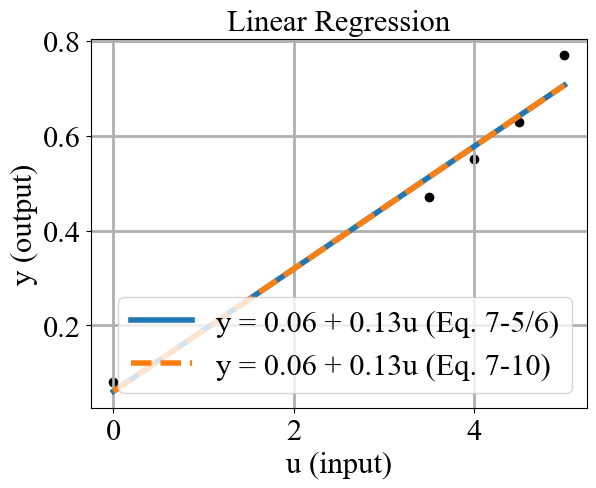

In [14]:
#_____________LINEAR REGRESSION___________________________

su=np.sum(ustate)
suu= np.sum(ustate**2)
sy= np.sum(ystate)
suy=np.sum(ystate@ustate)

beta1 = (suu*sy - suy*su)/(np.size(ustate)*suu - su**2) #Eq. 7-5
beta2 = (np.size(ustate)*suy - su*sy)/(np.size(ustate)*suu - su**2) #Eq. 7-6
k_gainLR = beta2

s = np.sum((ystate-beta1-beta2*ustate)**2) #Eq. 7-2
eq = beta1 + beta2*ustate #Eq. 7-3

#For general models
x = np.column_stack([np.ones(np.size(ustate)), ustate])
xt = np.transpose(x)
yt = np.transpose(ystate)

betas = np.linalg.inv(xt@x)@xt@ystate #Eq. 7-10
s_2 = np.transpose(ystate-x@betas)@(ystate-x@betas) #Eq. 7-9
eq_2 = betas[0] + betas[1]*ustate #Eq. 7-3
k_gainLR2= betas[1]

print('Resultado modelo linear ---> Gain (K):',k_gainLR,'erro:',s)
print('Resultado modelo geral ---> Gain (K)',k_gainLR2,'erro',s_2)

plt.scatter(ustate,ystate, color = 'k')
plt.plot(ustate,eq, label = f'y = {beta1:.2f} + {beta2:.2f}u (Eq. 7-5/6)')
plt.plot(ustate,eq_2, '--', label = f'y = {betas[0]:.2f} + {betas[1]:.2f}u (Eq. 7-10)')
plt.title('Linear Regression')
plt.grid(True)
plt.legend()
plt.ylabel('y (output)')
plt.xlabel('u (input)')
plt.show()

[ 0.31269308 -0.51045352]
Erro Quadrático Médio (MSE) NONLINEAR REGRESSION: 0.004221
Erro Absoluto Médio (MAE) NONLINEAR REGRESSION: 0.048633
o valor de tau é ---> 1.9590422449591507


c:\Users\Julia\OneDrive\AnaJuliaBK0904\Mestrado PPGEM\2 Artigos\TuningPID2026\Revista polipapers\code\.venv\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\Julia\OneDrive\AnaJuliaBK0904\Mestrado PPGEM\2 Artigos\TuningPID2026\Revista polipapers\code\.venv\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


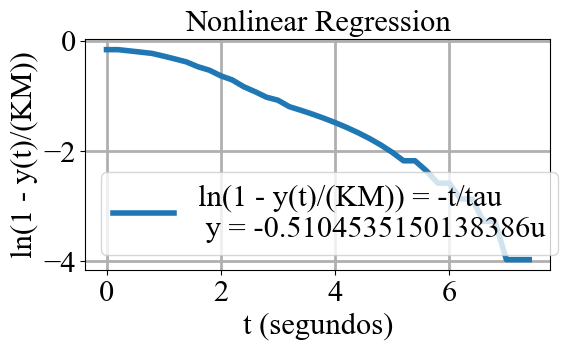

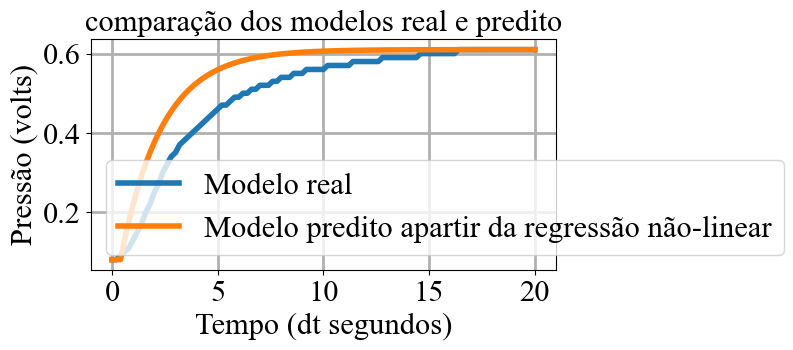

In [15]:
#_____________NONLINEAR REGRESSION___________________________
NR = np.log(1-(y/(y.iloc[-1]-y.iloc[0])))

#filtro para tirar valores infinitos
valid_points = np.isfinite(NR)
t_valid = t[valid_points]
NR = NR[valid_points]

#MINIMOS QUADRADOS PARA MODELOS GERAIS
xNR = np.column_stack([np.ones(np.size(t_valid)), t_valid])
xtNR = np.transpose(xNR)
ytNR = np.transpose(NR)
betaNR = np.linalg.inv(xtNR@xNR)@xtNR@NR #equacao 7-10
Sregressnonli = np.transpose(NR-xNR@betaNR)@(NR-xNR@betaNR)
yyy = betaNR[0] + betaNR[1]*t_valid #equacao 7-3
print(betaNR)
tauNR = -1/betaNR[1]

#equação analitica do modelo predito
yNLR = y.iloc[0] + (y.iloc[-1]-y.iloc[0])*(1-np.exp(-(t-delay)/tauNR)) * (t >= delay)
orderNLR = 1
#ERROR
#______________________________________________________________________________
# 1. ERRO QUADRÁTICO MÉDIO (MSE) - RECOMENDADO
mseNLR = np.mean((y - yNLR)**2)
print(f"Erro Quadrático Médio (MSE) NONLINEAR REGRESSION: {mseNLR:.6f}")
#______________________________________________________________________________
# 3. ERRO ABSOLUTO MÉDIO (MAE)
maeNLR = np.mean(np.abs(y - yNLR))
print(f"Erro Absoluto Médio (MAE) NONLINEAR REGRESSION: {maeNLR:.6f}")
#______________________________________________________________________________

#plot da regressão nao linear
plt.figure(figsize=(6, 3))
plt.plot(t_valid,NR,label=f'ln(1 - y(t)/(KM)) = -t/tau \n y = {betaNR[1]}u')
plt.title('Nonlinear Regression')
plt.grid(True)
plt.ylabel('ln(1 - y(t)/(KM))')
plt.legend()
plt.xlabel('t (segundos)')
print('o valor de tau é --->',tauNR)

#plot do modelo predito e dos dados medidos
plt.figure(figsize=(6, 3))
plt.plot(t,y,label='Modelo real')
plt.plot(t,yNLR,label='Modelo predito apartir da regressão não-linear')
plt.title('comparação dos modelos real e predito')
plt.grid(True)
plt.legend()
plt.ylabel('Pressão (volts)')
plt.xlabel('Tempo (dt segundos)')
plt.show()

Os valores de K (gain) e tau são, respectivamente pelo método 63,2%: 0.11777777777777779 3.6992000000000016
Os valores de tau (seg) e zeta pelo método de Smith são, respectivamente: 1.8058916645382093 e 1.0429894654303673
Erro Quadrático Médio (MSE) 63,2% METHOD: 0.000082
Erro Absoluto Médio (MAE) SMITH METHOD: 0.006048
Erro Quadrático Médio (MSE): 0.000545
Erro Absoluto Médio (MAE): 0.017745


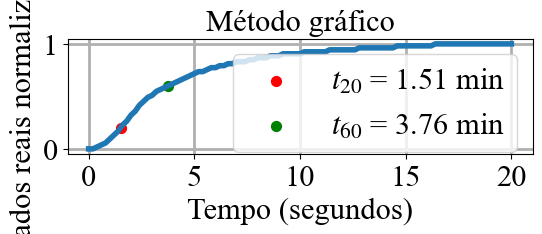

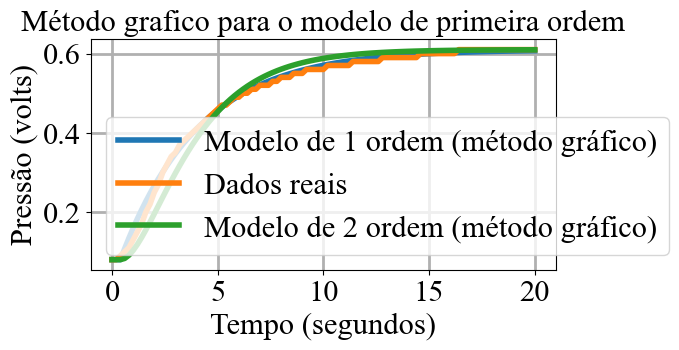

In [16]:
#_____________63,2% METHOD___________________________
dx2_632 = (y.iloc[-1]-y.iloc[0])*0.632 + y.iloc[0]
tau_632 = np.interp(dx2_632,y,t) - delay

#calculo do ganho estatico
dV = StepValue
dP = y.iloc[-1]-y.iloc[0]
k_gain632 = (dP)/(dV)

#metodo grafico para obter modelo preditos de primeira ordem
y632 = y.iloc[0] + StepValue*k_gain632*(1-np.exp(-(t-delay)/tau_632)) * (t >= delay)
print('Os valores de K (gain) e tau são, respectivamente pelo método 63,2%:',k_gain632, tau_632)
order632 = 1
#_____________SMITH METHOD___________________________
x2_norml = (y-y.iloc[0])/(y.iloc[-1]-y.iloc[0])

dx2_20 = 0.2
dx2_60 = 0.6
tau_20 = np.interp(dx2_20,x2_norml,t) #esta em millis e transformei para segundos multiplicando por 1000
tau_60 = np.interp(dx2_60,x2_norml,t)
tau20_tau60 = tau_20/tau_60 #segundo o grafico de smith's pode-se determinar os valores de tau e zeta

# Smith's method graph data
SmithValues = [
    [0.543322, 1.21112, 0.1],
    [0.537165, 1.239, 0.15],
    [0.530819, 1.26831, 0.2],
    [0.524283, 1.29914, 0.25],
    [0.517554, 1.3316, 0.3],
    [0.510633, 1.3658, 0.35],
    [0.503521, 1.40187, 0.4],
    [0.49622, 1.43992, 0.45],
    [0.488737, 1.48008, 0.5],
    [0.48108, 1.52248, 0.55],
    [0.473261, 1.56725, 0.6],
    [0.465296, 1.6145, 0.65],
    [0.457203, 1.66436, 0.7],
    [0.449008, 1.71693, 0.75],
    [0.440739, 1.77229, 0.8],
    [0.432429, 1.83049, 0.85],
    [0.424116, 1.89158, 0.9],
    [0.41584, 1.95554, 0.95],
    [0.407646, 2.02231, 1.0],
    [0.399578, 2.09182, 1.05],
    [0.391678, 2.16394, 1.1],
    [0.383989, 2.23849, 1.15],
    [0.376546, 2.31529, 1.2],
    [0.369382, 2.39411, 1.25],
    [0.362521, 2.47475, 1.3],
    [0.355981, 2.55696, 1.35],
    [0.349771, 2.64055, 1.4],
    [0.343897, 2.7253, 1.45],
    [0.338357, 2.81104, 1.5],
    [0.333144, 2.89762, 1.55],
    [0.32825, 2.98489, 1.6],
    [0.323661, 3.07274, 1.65],
    [0.319363, 3.16108, 1.7],
    [0.315342, 3.24982, 1.75],
    [0.311582, 3.3389, 1.8],
    [0.308066, 3.42827, 1.85],
    [0.30478, 3.51788, 1.9],
    [0.301708, 3.6077, 1.95],
    [0.298836, 3.6977, 2.0],
    [0.29615, 3.78785, 2.05],
    [0.293637, 3.87813, 2.1],
    [0.291286, 3.96853, 2.15],
    [0.289084, 4.05903, 2.2],
    [0.287021, 4.14962, 2.25],
    [0.285088, 4.24029, 2.3],
    [0.283274, 4.33103, 2.35],
    [0.281571, 4.42184, 2.4],
    [0.279971, 4.5127, 2.45],
    [0.278467, 4.60361, 2.5],
    [0.277052, 4.69456, 2.55],
    [0.275719, 4.78556, 2.6],
    [0.274463, 4.8766, 2.65],
    [0.273279, 4.96767, 2.7],
    [0.27216, 5.05878, 2.75],
    [0.271103, 5.14991, 2.8],
    [0.270103, 5.24107, 2.85],
    [0.269157, 5.33225, 2.9],
    [0.268261, 5.42346, 2.95],
    [0.26741, 5.51468, 3.0],
    [0.266604, 5.60593, 3.05],
    [0.265837, 5.69719, 3.1],
    [0.265109, 5.78847, 3.15],
    [0.264415, 5.87977, 3.2],
    [0.263755, 5.97108, 3.25],
    [0.263126, 6.06241, 3.3],
    [0.262526, 6.15374, 3.35],
    [0.261954, 6.24509, 3.4],
    [0.261407, 6.33645, 3.45],
    [0.260885, 6.42782, 3.5],
    [0.260385, 6.5192, 3.55],
    [0.259906, 6.61059, 3.6],
    [0.259448, 6.70199, 3.65],
    [0.259009, 6.7934, 3.7],
    [0.258589, 6.88482, 3.75],
    [0.258185, 6.97624, 3.8],
    [0.257797, 7.06767, 3.85],
    [0.257425, 7.1591, 3.9],
    [0.257067, 7.25055, 3.95],
    [0.256723, 7.34199, 4.0],
    [0.256392, 7.43345, 4.05],
    [0.256073, 7.52491, 4.1],
    [0.255766, 7.61637, 4.15],
    [0.255471, 7.70784, 4.2],
    [0.255186, 7.79932, 4.25],
    [0.254911, 7.8908, 4.3],
    [0.254646, 7.98228, 4.35],
    [0.25439, 8.07377, 4.4],
    [0.254142, 8.16526, 4.45],
    [0.253904, 8.25675, 4.5],
    [0.253673, 8.34825, 4.55],
    [0.25345, 8.43975, 4.6],
    [0.253234, 8.53126, 4.65],
    [0.253025, 8.62277, 4.7],
    [0.252823, 8.71428, 4.75],
    [0.252628, 8.8058, 4.8],
    [0.252438, 8.89731, 4.85],
    [0.252254, 8.98883, 4.9],
    [0.252076, 9.08036, 4.95],
    [0.251904, 9.17188, 5.0]
]
SmithValues_np = np.array(SmithValues)

# Seus dados (conforme explicado)
tau20_tau60_values = SmithValues_np[:, 0]  # Coluna 0: valores de tau20/tau60
tau60_over_tau_values = SmithValues_np[:, 1]  # Coluna 1: valores de tau60/tau
zeta_values = SmithValues_np[:, 2]  # Coluna 2: valores de zeta

# 1. Interpolar tau60/tau a partir de tau20/tau60
f_tau60_tau = interpolate.interp1d(tau20_tau60_values, tau60_over_tau_values,
                                  kind='linear', fill_value='extrapolate')
tau60_over_tau_interpolado = f_tau60_tau(tau20_tau60)

# 2. Interpolar zeta a partir de tau20/tau60
f_zeta = interpolate.interp1d(tau20_tau60_values, zeta_values,
                             kind='linear', fill_value='extrapolate')
zetaSMITH = f_zeta(tau20_tau60)

# 3. Agora calcular tau (se necessário)
tauSMITH = tau_60 / tau60_over_tau_interpolado
print('Os valores de tau (seg) e zeta pelo método de Smith são, respectivamente:',tauSMITH,'e', zetaSMITH)

if zetaSMITH>1: #Overdamped (zeta>1)
    #pelo modelo ser sobreamortecido necessita calcular as duas constantes de tempo tau1 e tau2
    tau1 = tauSMITH*zetaSMITH + tauSMITH*np.sqrt(zetaSMITH**2 - 1)
    tau2 = tauSMITH*zetaSMITH - tauSMITH*np.sqrt(zetaSMITH**2 - 1)

    #metodo grafico para obter modelos preditos de segunda ordem
    ySMITH = y.iloc[0] + k_gain632*StepValue*(1 + (1/(tau2 - tau1))*(tau1*np.exp(-(t-delay)/tau1) - tau2*np.exp(-(t-delay)/tau2)))* (t >= delay)
    orderSMITH = 2
    #print(tau20_tau60)

elif 0<=zetaSMITH<1:  #Underdamped (0=<zeta<1)
    #metodo grafico para obter modelos preditos de segunda ordem
    ySMITH = y.iloc[0] + k_gain632*StepValue*(1 - np.exp(-zetaSMITH*(t-delay)/tauSMITH)*(np.cos(((np.sqrt(1-zetaSMITH**2))/tauSMITH)*t) + (zetaSMITH/(np.sqrt(1-zetaSMITH**2)))*np.sin(((np.sqrt(1-zetaSMITH**2))/tauSMITH )*t)))* (t >= delay)
    orderSMITH = 2

else: #Critically Damped (zeta=1)
    #metodo grafico para obter modelos preditos de segunda ordem
    ySMITH = y.iloc[0] + k_gain632*StepValue*(1 - (1+(t-delay)/tauSMITH)*np.exp(-(t-delay)/tauSMITH))* (t >= delay)
    orderSMITH = 2
    
#ERROR
#______________________________________________________________________________
# 1. ERRO QUADRÁTICO MÉDIO (MSE) - RECOMENDADO
mse632 = np.mean((y - y632)**2)
print(f"Erro Quadrático Médio (MSE) 63,2% METHOD: {mse632:.6f}")
#______________________________________________________________________________
# 3. ERRO ABSOLUTO MÉDIO (MAE)
mae632 = np.mean(np.abs(y - y632))
print(f"Erro Absoluto Médio (MAE) SMITH METHOD: {mae632:.6f}")
#______________________________________________________________________________

#ERROR
#______________________________________________________________________________
# 1. ERRO QUADRÁTICO MÉDIO (MSE) - RECOMENDADO
mseSMITH = np.mean((y - ySMITH)**2)
print(f"Erro Quadrático Médio (MSE): {mseSMITH:.6f}")
#______________________________________________________________________________
# 3. ERRO ABSOLUTO MÉDIO (MAE)
maeSMITH = np.mean(np.abs(y - ySMITH))
print(f"Erro Absoluto Médio (MAE): {maeSMITH:.6f}")
#______________________________________________________________________________

plt.figure(figsize=(6, 1.5))
plt.scatter(tau_20, dx2_20, color='r', s=50, label=f'$t_{{20}}$ = {tau_20:.2f} min')
plt.scatter(tau_60, dx2_60, color='g', s=50, label=f'$t_{{60}}$ = {tau_60:.2f} min')
plt.plot(t,x2_norml)
plt.title('Método gráfico')
plt.legend()
plt.grid(True)
plt.ylabel('dados reais normalizados')
plt.xlabel('Tempo (segundos)')

plt.figure(figsize=(6, 3))
plt.plot(t,y632, label = 'Modelo de 1 ordem (método gráfico)')
plt.plot(t,y,label='Dados reais')
plt.plot(t,ySMITH, label = 'Modelo de 2 ordem (método gráfico)')
plt.title('Método grafico para o modelo de primeira ordem')
plt.grid(True)
plt.legend()
plt.ylabel('Pressão (volts)')
plt.xlabel('Tempo (segundos)')
plt.show()

a1 = 0.0054, a2 = 0.9612
Parâmetros estimados: τ = 5.06 s, K = 0.14
Erro Quadrático Médio (MSE) DISCRETE TIME METHOD: 0.001298
Erro Absoluto Médio (MAE) DISCRETE TIME METHOD: 0.030832


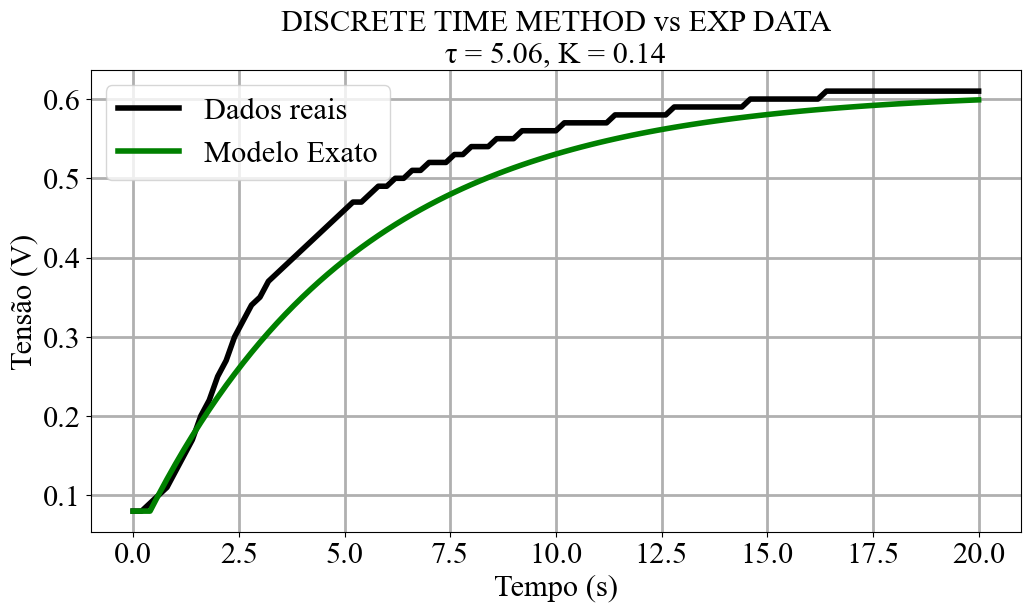

In [17]:
#_____________DISCRETE TIME METHOD___________________________
dt = t.iloc[1]-t.iloc[0]  # Intervalo de amostragem
# y[k] = a2 * y[k-1] + a1 * u[k-1]
# Criar vetores para a regressão
y_k = y[1:]          # y[k] para k = 1,2,...,n-1
y_km1 = y[:-1]       # y[k-1] para k = 1,2,...,n-1  
u_km1 = u[:-1]       # u[k-1] para k = 1,2,...,n-1
X = np.column_stack([y_km1, u_km1]) # Montar matriz de regressão X = [y[k-1], u[k-1]]

# Resolver sistema linear usando mínimos quadrados
coeffs, residuals, rank, s = np.linalg.lstsq(X, y_k, rcond=None)
a2 = coeffs[0]  # coeficiente de y[k-1]
a1 = coeffs[1]  # coeficiente de u[k-1]

# Calcular parâmetros do sistema
tauDTM = -dt / np.log(a2) if a2 > 0 else np.nan
k_gainDTM = a1 / (1 - np.exp(-dt/tauDTM)) if not np.isnan(tauDTM) else np.nan
print(f"a1 = {a1:.4f}, a2 = {a2:.4f}")
print(f"Parâmetros estimados: τ = {tauDTM:.2f} s, K = {k_gainDTM:.2f}")
#print(f"Parâmetros estimados para euler: tau = {taueuler:.2f} s, K = {Keuler:.2f}")

# Converter para arrays numpy para evitar problemas de índice
t_array = t.values
y_array = y.values
u_array = u.values

# Inicializar saídas
y_exato = np.zeros_like(y)
y_euler = np.zeros_like(y)
y_exato[0] = y_array[0]
y_euler[0] = y.iloc[0]

# Simulação
for k in range(1, len(y_array)):
    # Modelo exato
    y_exato[k] = np.exp(-dt/tauDTM)*y_array[k-1] + k_gainDTM*(1 - np.exp(-dt/tauDTM))*u_array[k-1]
    # Aproximação de Euler
    #y_euler[k] = (1 - dt/taueuler) * y_euler[k-1] + (Keuler * dt/taueuler) * u[k-1]
#yDTM = y.iloc[0] + StepValue*k_gainDTM*(1-np.exp(-(t-delay)/tauDTM)) * (t >= delay)
yDTM = y.iloc[0] + (y.iloc[-1]-y.iloc[0])*(1-np.exp(-(t-delay)/tauDTM)) * (t >= delay)
orderDTM = 1

#______________________________________________________________________________
# 1. ERRO QUADRÁTICO MÉDIO (MSE) - RECOMENDADO
mseDTM = np.mean((y - yDTM)**2)
print(f"Erro Quadrático Médio (MSE) DISCRETE TIME METHOD: {mseDTM:.6f}")
#______________________________________________________________________________
# 3. ERRO ABSOLUTO MÉDIO (MAE)
maeDTM = np.mean(np.abs(y - yDTM))
print(f"Erro Absoluto Médio (MAE) DISCRETE TIME METHOD: {maeDTM:.6f}")
#______________________________________________________________________________

# Plot
plt.figure(figsize=(12, 6))
#plt.step(t, u, 'r-', where='post', label='Entrada u(t)')
plt.plot(t, y, 'k-', label='Dados reais')
plt.plot(t, yDTM, 'g-', label='Modelo Exato')
#plt.plot(t, y_euler, 'b--', label='Aproximação Euler')
plt.title(f"DISCRETE TIME METHOD vs EXP DATA\nτ = {tauDTM:.2f}, K = {k_gainDTM:.2f}")
plt.xlabel("Tempo (s)")
plt.ylabel("Tensão (V)")
plt.grid(True)
plt.legend()
plt.show()

PARÂMETROS ENCONTRADOS:          τ:                    K:                     θ:                   τ₂:                      τ₁:                        τₐ                      ζ
REGRESSÃO LINEAR                                K = 0.129299,       θ = 0.400000 s
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
REGRESSÃO NÃO-LINEAR     τ = 1.959042 s,       K = 0.129299,       θ = 0.400000 s
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
MÉTODO 63,2%             τ = 3.699200 s,        K = 0.117778,       θ = 0.400000 s
-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------

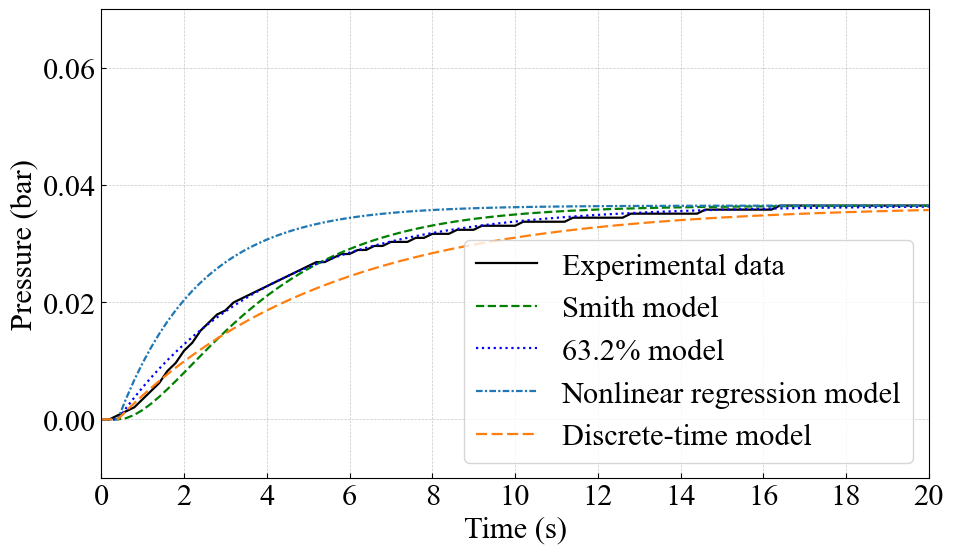

MELHOR MÉTODO POR CRITÉRIO:
Menor MSE: 632 = 0.000082
Menor MAE: 632 = 0.006048
⭐ MELHOR MÉTODO: 632
Variável 'ymodelfit' criada com dados do método 632
Variável 'ordermodelfit' criada com dados do método 632


In [18]:
#_____________MODELS COMPARATION AND ERRORS___________________________
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman"],
    "font.size": 22,          # semelhante ao texto do artigo
    "axes.labelsize": 22,
    "axes.titlesize": 22,
    "legend.fontsize": 22,
    "xtick.labelsize": 22,
    "ytick.labelsize": 22,
    "lines.linewidth": 4,
    "grid.linewidth": 2
})

plt.figure(figsize=(10, 6))
# Dicionário para armazenar os erros
errors = {}
# Dados reais
plt.plot(t, (y-0.08)*.344/5, 'k-', label='Experimental data', linewidth=1.6)
plt.plot(t, (ySMITH-0.08)*.344/5, 'g--', label='Smith model', linewidth=1.6)
plt.plot(t, (y632-0.08)*.344/5, 'b:', label='63.2% model', linewidth=1.6)
plt.plot(t, (yNLR-0.08)*.344/5, linestyle=(0,(3,1,1,1)), label='Nonlinear regression model', linewidth=1.6)
plt.plot(t, (yDTM-0.08)*.344/5, linestyle=(0,(5,2)), label='Discrete-time model', linewidth=1.6)

print("="*200)
print("PARÂMETROS ENCONTRADOS:          τ:                    K:                     θ:                   τ₂:                      τ₁:                        τₐ                      ζ")
print("="*200)
print(f"REGRESSÃO LINEAR                                K = {k_gainLR:.6f},       θ = {delay:.6f} s")
print("-"*200)
print(f"REGRESSÃO NÃO-LINEAR     τ = {tauNR:.6f} s,       K = {k_gainLR:.6f},       θ = {delay:.6f} s")
print("-"*200)
print(f"MÉTODO 63,2%             τ = {tau_632:.6f} s,        K = {k_gain632:.6f},       θ = {delay:.6f} s")
print("-"*200)
print(f"MÉTODO SMITH             τ = {tauSMITH:.6f} s,         K = {k_gainLR:.6f},        θ = {delay:.6f} s                                                                                  ζ = {tauSMITH:.6f} s,")
print("-"*200)  
print(f"MÉTODO TEMPO DISCRETO    τ = {tauDTM:.6f} s,        K = {k_gainDTM:.6f},       θ = {delay:.6f} s")                                      
print("-"*200)

print("="*50)
print("ERROS:")
print("="*50)
print(f"ERRO QUADRÁTICO MÉDIO (MSE) NLR= {mseNLR:.6f} s")
print(f"ERRO ABSOLUTO MÉDIO (MAE) = {maeNLR:.6f} s")
print("-"*50)
print(f"ERRO QUADRÁTICO MÉDIO (MSE) 632= {mse632:.6f} s")
print(f"ERRO ABSOLUTO MÉDIO (MAE) = {mae632:.6f} s")
print("-"*50)
print(f"ERRO QUADRÁTICO MÉDIO (MSE) SMITH= {mseSMITH:.6f} s")
print(f"ERRO ABSOLUTO MÉDIO (MAE) = {maeSMITH:.6f} s")
print("-"*50)
print(f"ERRO QUADRÁTICO MÉDIO (MSE) DTM= {mseDTM:.6f} s")
print(f"ERRO ABSOLUTO MÉDIO (MAE) = {maeDTM:.6f} s")
print("="*50)

#plt.title('Plant models versus experimental data')
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
plt.legend(frameon=True, loc='lower right')
plt.ylabel('Pressure (bar)')
plt.xlabel('Time (s)')
plt.ylim(-0.01, 0.07)
plt.xlim(0, 20)
plt.xticks(range(0, 21, 2))
plt.tick_params(direction='in')
plt.tight_layout()
plt.show()

# Análise rápida e direta
erros_dict = {
    'NLR': {'mse': mseNLR, 'mae': maeNLR, 'ymodel': yNLR, 'order': orderNLR, 'tau': tauNR, 'K': k_gainLR, 'tau_1': 0, 'tau_2': 0},
    '632': {'mse': mse632, 'mae': mae632, 'ymodel': y632, 'order': order632, 'tau': tau_632, 'K': k_gain632, 'tau_1': 0, 'tau_2': 0},
    'SMITH': {'mse': mseSMITH, 'mae': maeSMITH, 'ymodel': ySMITH, 'order': orderSMITH, 'tau': tauSMITH, 'K': k_gain632, 'tau_1': 0, 'tau_2': 0},
    'DTM': {'mse': mseDTM, 'mae': maeDTM, 'ymodel': yDTM, 'order': orderDTM, 'tau': tauDTM, 'K': k_gainDTM, 'tau_1': 0, 'tau_2': 0}
}

# Encontrar mínimos
melhor_mse = min(erros_dict, key=lambda x: erros_dict[x]['mse'])
melhor_mae = min(erros_dict, key=lambda x: erros_dict[x]['mae'])

print("="*50)
print("MELHOR MÉTODO POR CRITÉRIO:")
print("="*50)
print(f"Menor MSE: {melhor_mse} = {erros_dict[melhor_mse]['mse']:.6f}")
print(f"Menor MAE: {melhor_mae} = {erros_dict[melhor_mae]['mae']:.6f}")

# Decisão final
if melhor_mse == melhor_mae:
    print(f"⭐ MELHOR MÉTODO: {melhor_mse}")
    ymodelfit = erros_dict[melhor_mse]['ymodel']  # Criar variável com dados do melhor método
    ordermodelfit = erros_dict[melhor_mse]['order']
    K = erros_dict[melhor_mse]['K']
    tau = erros_dict[melhor_mse]['tau']
    tau_1 = erros_dict[melhor_mse]['tau_1']
    tau_2 = erros_dict[melhor_mse]['tau_2']
    print(f"Variável 'ymodelfit' criada com dados do método {melhor_mse}")
    print(f"Variável 'ordermodelfit' criada com dados do método {melhor_mse}")
else:
    print("📊 Métodos diferentes se destacam em cada métrica")
    print(f"Para precisão geral: {melhor_mse} (melhor MSE)")
    print(f"Para robustez: {melhor_mae} (melhor MAE)")

    # Decidir qual usar baseado em prioridade (MSE tem prioridade aqui)
    metodo_escolhido = melhor_mse  # Priorizando MSE
    ymodelfit = erros_dict[metodo_escolhido]['ymodel']
    ordermodelfit = erros_dict[metodo_escolhido]['order']
    print(f"Variável 'ymodelfit' criada com dados do método {metodo_escolhido} (prioridade MSE)")
    print(f"Variável 'ordermodelfit' criada com dados do método {metodo_escolhido} (prioridade MSE)")

Pontos onde a reta tangente cruza:
x2 = 0.08 → t = 0.640000 s, coeficiente angular 0.12500000000000056
x2 = 0.61 → t = 4.880000 s, coeficiente angular 0.12500000000000056
-----------------------------------------------------------------
Os parametros para o controle P é: Kp = 12.499999999999883
Os parametros para o controle PI é: Kp = 11.249999999999895, Ti = 2.1333333333333533
Os parametros para o controle PID é: Kp = 14.999999999999858, Ti = 1.280000000000012, Td = 0.320000000000003


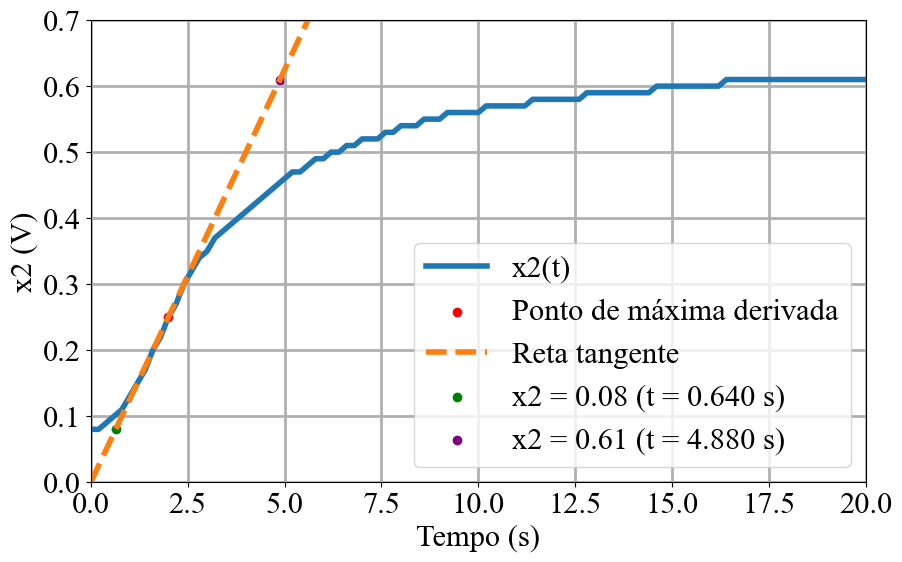

In [19]:
#_____________CONTROL TUNNING: ZIGLER NICHOLS___________________________

# Calcular a derivada numérica
dx2_dt = np.gradient(y, t)
    
# Encontrar o ponto onde a derivada é máxima
idx_max_deriv = np.argmax(dx2_dt)
t_max_deriv = t.iloc[idx_max_deriv]
x2_max_deriv = y.iloc[idx_max_deriv]

# Equação da reta tangente: x2 = a * t + b
a = dx2_dt[idx_max_deriv]  # Coeficiente angular (derivada no ponto)
b = x2_max_deriv - a * t_max_deriv  # Coeficiente linear

# Definir os valores de x2 desejados
x2_targets = [y.iloc[0], y.iloc[-1]]

# Calcular os tempos correspondentes
t_crossings = [(target - b) / a for target in x2_targets]

R = x2_max_deriv/t_max_deriv
L = t_crossings[0]

#CONTROLADOR P
Kp1 = 1/(R*L)

#CONTROLADOR PI
Kp2 = 0.9/(R*L)
Ti2 = L/0.3

#CONTROLADOR PID
Kp3 = 1.2/(R*L)
Ti3 = L/(0.5)
Td3 = 0.5*L

# Resultados
print("Pontos onde a reta tangente cruza:")
for target, t_cross in zip(x2_targets, t_crossings):
    print(f"x2 = {target} → t = {t_cross:.6f} s, coeficiente angular {a}")

print('-----------------------------------------------------------------')
print(f'Os parametros para o controle P é: Kp = {Kp1}')
print(f'Os parametros para o controle PI é: Kp = {Kp2}, Ti = {Ti2}')
print(f'Os parametros para o controle PID é: Kp = {Kp3}, Ti = {Ti3}, Td = {Td3}')

# Gráfico
plt.figure(figsize=(10, 6))
plt.plot(t, y, label='x2(t)')
plt.scatter(t_max_deriv, x2_max_deriv, color='red', label='Ponto de máxima derivada')

# Plotar a reta tangente
t_tangent = np.linspace(t.min(), t.max(), 100)
x2_tangent = a * t_tangent + b
plt.plot(t_tangent, x2_tangent, '--', label='Reta tangente')

# Marcar os cruzamentos com x2 = 0.08 e x2 = 0.63
colors = ['green', 'purple']
for target, t_cross, color in zip(x2_targets, t_crossings, colors):
    plt.scatter(t_cross, target, color=color, label=f'x2 = {target} (t = {t_cross:.3f} s)')

plt.xlabel('Tempo (s)')
plt.ylabel('x2 (V)')
plt.ylim(0,0.7)
plt.xlim(0,20)
plt.legend()
plt.grid()
plt.show()

In [20]:
#_____________CONTROL TUNNING: DIRECTED SYNTHESIS___________________________
# Valores de tau_c
tau_c_values = [1, 3, 10]

# Vetores para armazenar os resultados
Kc_list = []
tau_I_list = []
tau_D_list = []

if ordermodelfit == 1:  
    # Controle PI para cada tau_c
    for tau_c in tau_c_values:
        Kc = 1/K * tau/(delay + tau_c)
        tau_I = tau
        
        # Armazena nos vetores
        Kc_list.append(Kc)
        tau_I_list.append(tau_I)
        tau_D_list.append(None)  # Não tem tau_D no PI

else: 
    # Controle PID para cada tau_c
    for tau_c in tau_c_values:
        Kc = 1/K * (tau_1 + tau_2)/(delay + tau_c)
        tau_I = tau_1 + tau_2
        tau_D = (tau_1 * tau_2)/(tau_1 + tau_2)
        
        # Armazena nos vetores
        Kc_list.append(Kc)
        tau_I_list.append(tau_I)
        tau_D_list.append(tau_D)

# Agora você tem os vetores com os resultados:
print("Kc values:", Kc_list)
print("tau_I values:", tau_I_list)
print("tau_D values:", tau_D_list)

Kc values: [np.float64(22.434501347708903), np.float64(9.237735849056607), np.float64(3.0200290275761983)]
tau_I values: [np.float64(3.6992000000000016), np.float64(3.6992000000000016), np.float64(3.6992000000000016)]
tau_D values: [None, None, None]


In [21]:
#_____________CONTROL TUNNING: INTERNAL MODEL CONTROL___________________________

# Valores de tau_c
tau_c_values = [1, 3, 10]

# Vetores para armazenar os resultados
Kc_listIMC = []
tau_I_listIMC = []
tau_D_listIMC = []

if ordermodelfit == 1:  
    # Controle PID para cada tau_c
    for tau_c in tau_c_values:
        KcIMC = 1/K * (delay/2 + tau)/(delay/2 + tau_c)
        tau_IIMC = delay/2 + tau
        tau_DIMC = (delay * tau)/(delay + tau*2)

        # Armazena nos vetores
        Kc_listIMC.append(KcIMC)
        tau_I_listIMC.append(tau_IIMC)
        tau_D_listIMC.append(tau_DIMC) 

elif tau_1 == 0: 
    # Controle PID para cada tau_c
    for tau_c in tau_c_values:
        KcIMC = 1/K * (tau_1 + tau_2)/(tau_c)
        tau_IIMC = tau_1 + tau_2
        tau_DIMC = (tau_1 * tau_2)/(tau_1 + tau_2)
        
        # Armazena nos vetores
        Kc_listIMC.append(KcIMC)
        tau_I_listIMC.append(tau_IIMC)
        tau_D_listIMC.append(tau_DIMC)

else: 
    # Controle PID para cada tau_c
    for tau_c in tau_c_values:
            KcIMC = 1/K * (2*zetaSMITH*tau)/(tau_c)
            tau_IIMC = 2*zetaSMITH*tau
            tau_DIMC = (tau)/(2*zetaSMITH)
            
            # Armazena nos vetores
            Kc_listIMC.append(KcIMC)
            tau_I_listIMC.append(tau_IIMC)
            tau_D_listIMC.append(tau_DIMC)

# Agora você tem os vetores com os resultados:
print("Kc values:", Kc_listIMC)
print("tau_I values:", tau_I_listIMC)
print("tau_D values:", tau_D_listIMC)

Kc values: [np.float64(27.58867924528303), np.float64(10.345754716981133), np.float64(3.2457269700332976)]
tau_I values: [np.float64(3.8992000000000018), np.float64(3.8992000000000018), np.float64(3.8992000000000018)]
tau_D values: [np.float64(0.18974148543290933), np.float64(0.18974148543290933), np.float64(0.18974148543290933)]


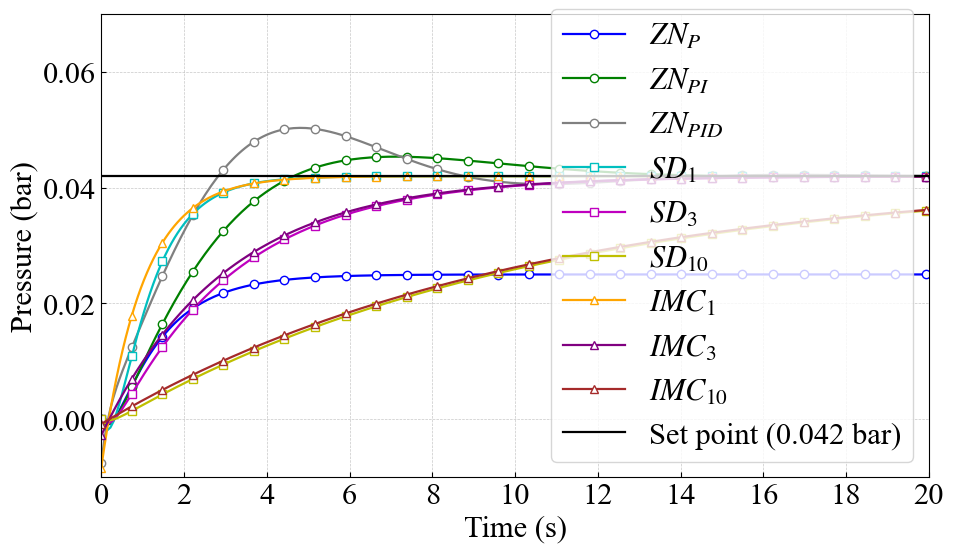


Análise de Estabilidade:

$ZN_P$:
  Polos: [-4.04656754+0.j -0.82577723+0.j]
  O sistema é estável (todos os polos no semiplano esquerdo).

$ZN_{PI}$:
  Polos: [-4.26014315+0.j         -0.32600001+0.30130133j -0.32600001-0.30130133j]
  O sistema é estável (todos os polos no semiplano esquerdo).

$ZN_{PID}$:
  Polos: [-5.95402488+0.j         -0.30264209+0.52749972j -0.30264209-0.52749972j]
  O sistema é estável (todos os polos no semiplano esquerdo).

$SD_1$:
  Polos: [-3.15300969+0.j -1.1327046 +0.j -0.27032872+0.j]
  O sistema é estável (todos os polos no semiplano esquerdo).

$SD_3$:
  Polos: [-4.36931018+0.j -0.33657218+0.j -0.27032872+0.j]
  O sistema é estável (todos os polos no semiplano esquerdo).

$SD_{10}$:
  Polos: [-4.80376439+0.j -0.27032872+0.j -0.10008177+0.j]
  O sistema é estável (todos os polos no semiplano esquerdo).

$IMC_1$:
  Polos: [-5.        +0.j -1.        +0.j -0.27032872+0.j]
  O sistema é estável (todos os polos no semiplano esquerdo).

$IMC_3$:
  Polos: [-

In [22]:
from scipy import signal
import control
from scipy.signal import find_peaks
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times"],
    "mathtext.fontset": "stix",
    "mathtext.rm": "Times New Roman",
    "mathtext.it": "Times New Roman:italic",
    "mathtext.bf": "Times New Roman:bold"
})
#_____________CONTROLS PARAMETERS___________________________
controls = {
    '$ZN_P$': {'type': 'P', 'Kc': Kp1, 'tau_I': None, 'tau_D': None},
    '$ZN_{PI}$': {'type': 'PI', 'Kc': Kp2, 'tau_I': Ti2, 'tau_D': None},
    '$ZN_{PID}$': {'type': 'PID', 'Kc': Kp3, 'tau_I': Ti3, 'tau_D': Td3},
    '$SD_1$': {'type': 'PID', 'Kc': Kc_list[0], 'tau_I': tau_I_list[0], 'tau_D': tau_D_list[0]},
    '$SD_3$': {'type': 'PID', 'Kc': Kc_list[1], 'tau_I': tau_I_list[1], 'tau_D': tau_D_list[1]},
    '$SD_{10}$': {'type': 'PID', 'Kc': Kc_list[2], 'tau_I': tau_I_list[2], 'tau_D': tau_D_list[2]},
    '$IMC_1$': {'type': 'PID', 'Kc': Kc_listIMC[0], 'tau_I': tau_I_listIMC[0], 'tau_D': tau_D_listIMC[0]},
    '$IMC_3$': {'type': 'PID', 'Kc': Kc_listIMC[1], 'tau_I': tau_I_listIMC[1], 'tau_D': tau_D_listIMC[1]},
    '$IMC_{10}$': {'type': 'PID', 'Kc': Kc_listIMC[2], 'tau_I': tau_I_listIMC[2], 'tau_D': tau_D_listIMC[2]}
    }


#_____________CONFIGURAÇÃO DA SIMULAÇÃO___________________________
t = np.linspace(0, 60, 814)
reference = y.iloc[-1] * np.ones_like(t)*0.344/5
num_delay, den_delay = control.pade(delay, 1)

#_____________FUNÇÃO DA PLANTA___________________________
# Função de transferência da planta
if ordermodelfit == 1:
    num_plant = [K]
    den_plant = [tau, 1]
    G_plant = control.tf(num_plant, den_plant) * control.tf(num_delay, den_delay)
    plant_info = r'$G(s) = \frac{' + f"{K:.3f}" + r'}{' + f"{tau:.3f}" + r's + 1} \cdot e^{-' + f"{delay}" + r's}$'

elif ordermodelfit == 2:
    # Sistema de 2ª ordem (forma padrão: K/((tau1*s + 1)(tau2*s + 1)))
    if tau_1 != 0 and tau_2 != 0:
        num_plant = [K]
        den_plant = [tau_1 * tau_2, tau_1 + tau_2, 1]
        G_plant = control.tf(num_plant, den_plant) * control.tf(num_delay, den_delay)
        plant_info = f"G(s) = {K}/(({tau_1}s + 1)({tau_2}s + 1)) * e^(-{delay}s)"
    else:
        print("Erro: tau_1 e tau_2 devem ser diferentes de zero para sistema de 2ª ordem")
        # Tratamento de erro ou valor default

else:  
    num_plant = [K]
    den_plant = [tau**2, 2*zetaSMITH*tau, 1]
    G_plant = control.tf(num_plant, den_plant) * control.tf(num_delay, den_delay)
    plant_info = f"G(s) = {K}/({tau**2}s² + {2*zetaSMITH*tau}s + 1) * e^(-{delay}s)"

#_____________SIMULAÇÃO DOS 9 CONTROLADORES___________________________
plt.figure(figsize=(10, 6))
colors = ['b', 'g', 'gray', 'c', 'm', 'y', 'orange', 'purple', 'brown']
linestyles = ['-','-','-','-','-','-','-','-','-',]
marker = ['o','o','o','s','s','s','^','^','^']
results = {}

for i, (control_name, params) in enumerate(controls.items()):
    # Criar função de transferência do controlador
    if params['type'] == 'P':
        num_controller = [params['Kc']]
        den_controller = [1]
        controller_info = f"$K_c$ = {params['Kc']:2f}"
        
    elif params['type'] == 'PI' or params['tau_D'] is None:
        num_controller = [params['Kc'] * params['tau_I'], params['Kc']]
        den_controller = [params['tau_I'], 0]
        controller_info = f"$K_c$ = {params['Kc']:.2f}, $τ_I$ = {params['tau_I']:.2f}"
        
    elif params['type'] == 'PID':
        if params['tau_D'] is not None:
                num_controller = [params['Kc'] * params['tau_I'] * params['tau_D'], 
                                 params['Kc'] * params['tau_I'], 
                                 params['Kc']]
                den_controller = [params['tau_I'], 0]
                controller_info = f"$K_c$ = {params['Kc']:.2f}, $\\tau_I$ = {params['tau_I']:.2f}, $\\tau_D$ = {params['tau_D']:.2f}"
    
    G_controller = control.tf(num_controller, den_controller)
    G_closed = control.feedback(G_controller * G_plant, 1)
    
    # Calcular os polos do sistema em malha fechada
    poles = control.poles(G_closed)
    # Verificar estabilidade (todos os polos com parte real negativa)
    is_stable = all(np.real(p) < -1e-6 for p in poles)
    
    # Simular resposta
    time, response = control.step_response(y.iloc[-1] * G_closed, t)
    
    # Armazenar resultados
    results[control_name] = {
        'time': time,
        'response': response,
        'controller_info': controller_info,
        'poles': poles,
        'is_stable': is_stable
    }
    
    response = response*0.344/5
    # Plot
    plt.plot(time, response, color=colors[i], linestyle=linestyles[i], 
             linewidth=1.6,marker = marker[i],markerfacecolor='white',markevery=10, label=f'{control_name}')#:{controller_info}')

#_____________PLOT FINAL___________________________
plt.plot(t, reference, 'k', linewidth=1.6, label=f'Set point ({y.iloc[-1]*0.344/5:.3f} bar)')
plt.xlabel('Time (s)')
plt.ylabel('Pressure (bar)')
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
plt.legend(frameon=True, loc='lower right')
plt.tick_params(direction='in')
plt.ylim(-0.01, 0.07)
plt.xlim(0, 20)
plt.xticks(range(0, 21, 2))
plt.tight_layout()
plt.show()


# Exibir polos e estabilidade para cada controlador
print("\nAnálise de Estabilidade:")
for control_name, data in results.items():
    poles = data['poles']
    is_stable = data['is_stable']
    print(f"\n{control_name}:")
    print(f"  Polos: {poles}")
    if is_stable:
        print("  O sistema é estável (todos os polos no semiplano esquerdo).")
    else:
        print("  O sistema é instável (há polo(s) com parte real >= 0).")

In [23]:
#_____________ANÁLISE E SELEÇÃO DO MELHOR CONTROLADOR___________________________
print("="*160)
print("SELEÇÃO DO MELHOR CONTROLADOR")
print("="*160)

# Criar lista para armazenar métricas de desempenho
performance_metrics = []

for control_name, data in results.items():
    response = data['response']
    time = data['time']
    
    # OVERSHOOT
    overshoot = 0
    if max(response) > y.iloc[-1]:
        overshoot = ((max(response) - y.iloc[-1]) / y.iloc[-1]) * 100
     
    # SETTLING TIME
    # Verificar se o sistema permanece dentro de 5% até o final
    # Encontrar o último ponto onde sai fora de 5%
    within_2percent = np.abs(response - y.iloc[-1]) <= 0.05 * y.iloc[-1]
    # Verificar de trás para frente para encontrar estabilização definitiva
    for i in range(len(response)-1, -1, -1):
        if not within_2percent[i]:
                # Se encontrou um ponto fora de 5%, o tempo de estabilização é o próximo ponto
            if i < len(response) - 1:
                settling_time = time[i + 1]
            else:
                settling_time = time[-1]  # Nunca estabilizou
            break
    else:
        # Se nunca saiu de 5%, estabilizou desde o início
        settling_time = time[0]
    
    # OFF SET
    off_set = abs(y.iloc[-1] - response[-1])
    
    # RISE TIME
    rise_time = 0
    try:
        if overshoot != 0:  
            # Caso tenha overshoot: tempo até atingir o valor final pela primeira vez
            idx_final = np.where(response >= y.iloc[-1])[0]
            if len(idx_final) > 0:
                rise_time = time[idx_final[0]]
        else:
            # Caso sem overshoot: definição clássica (10% a 90%)
            idx_10 = np.where(response >= 0.1 * y.iloc[-1])[0]
            idx_90 = np.where(response >= 0.9 * y.iloc[-1])[0]
               
            if len(idx_10) > 0 and len(idx_90) > 0:
                idx_10_val = idx_10[0]
                idx_90_val = idx_90[0]
                if idx_90_val > idx_10_val:
                    rise_time = time[idx_90_val] - time[idx_10_val]
    except:
            rise_time = time[-1]
    
    # IAE (Integral Absolute Error)
    iae = np.trapezoid(np.abs(y.iloc[-1] - response), time)
    
    # ISE (Integral Squared Error)
    ise = np.trapezoid((y.iloc[-1] - response)**2, time)
    
    # ITAE (Integral Time Absolute Error)
    itae = np.trapezoid(time * np.abs(y.iloc[-1] - response), time)
    
    performance_metrics.append({
        'name': control_name,
        'controller_info': data['controller_info'],
        'OS': overshoot,
        'ts': settling_time,
        'ot': off_set,
        'tr': rise_time,
        'iae': iae,
        'ise': ise,
        'itae': itae,
    })

# python
# _____________CRITÉRIOS DE SELEÇÃO___________________________
# Pesos para cada métrica - ajuste conforme sua prioridade
weights = {
    'overshoot': 0.15,      # Quanto menor, melhor
    'settling_time': 0.15,  # Quanto menor, melhor
    'off_set': 0.30,        # Erro em regime permanente. Quanto menor, melhor (geralmente alta prioridade)
    'rise_time': 0.15,      # Quanto menor, melhor
    'iae': 0.25,            # Integral do erro absoluto. Quanto menor, melhor
}

# 1. Separar controladores estáveis dos instáveis
stable_metrics = []
unstable_metrics = []

# Adicionando a chave 'is_stable' de volta ao dicionário de métricas para facilitar o acesso
for metric in performance_metrics:
    control_name = metric['name']
    metric['is_stable'] = results[control_name]['is_stable']
    
    if metric['is_stable']:
        stable_metrics.append(metric)
    else:
        # Controladores instáveis recebem score nulo ou negativo para irem para o fim da lista
        metric['score'] = -1.0 
        unstable_metrics.append(metric)

# 2. Normalizar e calcular o score APENAS para os controladores estáveis
if stable_metrics:
    # Encontrar os valores máximos para normalização (o "pior" caso entre os estáveis)
    # Adicionamos 1e-9 para evitar divisão por zero se o valor máximo for 0
    max_os = max(m['OS'] for m in stable_metrics) + 1e-9
    max_ts = max(m['ts'] for m in stable_metrics) + 1e-9
    max_ot = max(m['ot'] for m in stable_metrics) + 1e-9
    max_tr = max(m['tr'] for m in stable_metrics) + 1e-9
    max_iae = max(m['iae'] for m in stable_metrics) + 1e-9
    
    # Calcular o score para cada controlador estável
    for metric in stable_metrics:
        # A fórmula (1 - valor_normalizado) garante que um valor MENOR da métrica resulte em um score MAIOR
        score_os = weights['overshoot'] * (1 - metric['OS'] / max_os)
        score_ts = weights['settling_time'] * (1 - metric['ts'] / max_ts)
        score_ot = weights['off_set'] * (1 - metric['ot'] / max_ot)
        score_tr = weights['rise_time'] * (1 - metric['tr'] / max_tr)
        score_iae = weights['iae'] * (1 - metric['iae'] / max_iae)
        
        metric['score'] = score_os + score_ts + score_ot + score_tr + score_iae

# 3. Juntar as listas e ordenar pelo score (maior score é melhor)
all_metrics_sorted = sorted(stable_metrics + unstable_metrics, key=lambda x: x['score'], reverse=True)

# _____________EXIBIÇÃO DOS RESULTADOS___________________________
print("="*160)
print("🏆 RANKING COMPLETO DOS CONTROLADORES")
print("="*160)
print(f"{'Rank':<5} {'Nome':<20} {'Score':<10} {'Polos':<10} {'Overshoot(%)':<15} {'SettlingTime(s)':<20} {'Offset':<10} {'RiseTime(s)':<15} {'ErroAbs':<10}")
print("-"*160)

for i, metric in enumerate(all_metrics_sorted):
    rank = i + 1
    nome = metric['name']
    score = f"{metric['score']:.3f}" if metric['score'] != -1 else "N/A (Instável)"
    estavel = "Estável" if metric['is_stable'] else "Instável"
    overshoot = f"{metric['OS']:.2f}"
    ts = f"{metric['ts']:.2f}"
    offset = f"{metric['ot']:.4f}"
    risetime = f"{metric['tr']:.4f}"
    erroabs = f"{metric['iae']:.4f}"
    
    print(f"{rank:<5} {nome:<20} {score:<10} {estavel:<10} {overshoot:<15} {ts:<20} {offset:<12}{risetime:<15}{erroabs:<10}")

# _____________MELHOR CONTROLADOR___________________________
best_controller = None
if stable_metrics:
    best_controller = all_metrics_sorted[0] # O primeiro da lista ordenada é o melhor estável

print("\n" + "="*160)
print("✨ MELHOR CONTROLADOR SELECIONADO")
print("="*160)

if best_controller:
    print(f"Nome: {best_controller['name']}")
    print(f"Configuração: {best_controller['controller_info']}")
    print(f"✅ SISTEMA ESTÁVEL")
    print(f"Score: {best_controller['score']:.3f}")
    print(f"Overshoot: {best_controller['OS']:.2f}%")
    print(f"Tempo de Acomodação (ts): {best_controller['ts']:.2f}s")
    print(f"Tempo de Subida (tr): {best_controller['tr']:.2f}s")
    print(f"Erro em Regime (Offset): {best_controller['ot']:.4f}")
    print(f"IAE: {best_controller['iae']:.3f}")
else:
    print("⚠️ NENHUM CONTROLADOR ESTÁVEL FOI ENCONTRADO!")
    print("Recomendação: Ajuste os parâmetros dos controladores ou verifique o modelo da planta.")

SELEÇÃO DO MELHOR CONTROLADOR
🏆 RANKING COMPLETO DOS CONTROLADORES
Rank  Nome                 Score      Polos      Overshoot(%)    SettlingTime(s)      Offset     RiseTime(s)     ErroAbs   
----------------------------------------------------------------------------------------------------------------------------------------------------------------
1     $SD_1$               0.969      Estável    0.00            3.25                 0.0000      2.1402         0.8538    
2     $IMC_3$              0.919      Estável    0.00            9.23                 0.0000      6.6421         1.9521    
3     $SD_3$               0.917      Estável    0.00            9.37                 0.0000      6.5683         2.0739    
4     $ZN_{PI}$            0.872      Estável    8.03            9.82                 0.0000      4.6494         1.4941    
5     $IMC_1$              0.830      Estável    0.00            3.25                 0.0000      37.4908        0.7323    
6     $ZN_{PID}$           0

Erro Quadrático Médio (MSE) DISCRETE TIME METHOD METHOD sd1: 0.000032
Erro Quadrático Médio (MSE) DISCRETE TIME METHOD METHOD sd3: 0.000023
Erro Quadrático Médio (MSE) DISCRETE TIME METHOD METHOD sd10: 0.000021


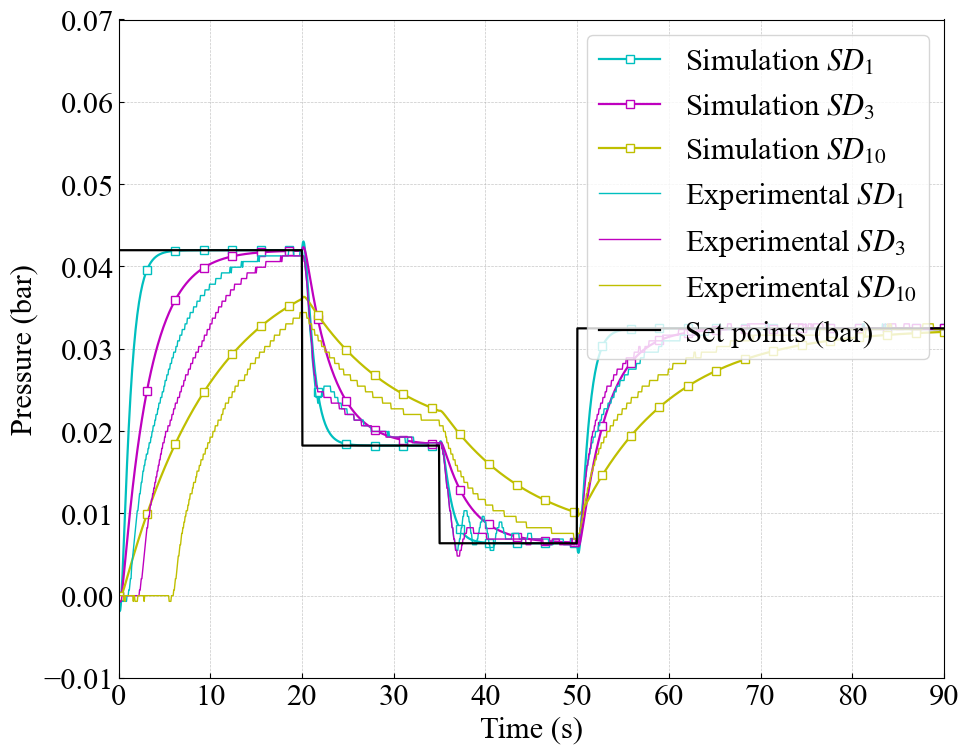

In [24]:
# Simular reposta com multiplos degraus
t = np.linspace(0, 90, 1451)
u = np.zeros_like(t)
#u[t >= 0] = 0.08
u[t >= 0] = 0.69
u[t >= 20] = 0.5 * 0.69
u[t >= 35] = 0.25 * 0.69
u[t >= 50] = 0.8 * 0.69
u = (u*0.344/5)-0.0055

info_string = best_controller['controller_info']

# 2. Extrai o valor de k_best (Kc)
kc_string = info_string.split(',')[0].split('=')[1]
k_best = float(kc_string.strip())

# 3. Extrai o valor de tau_best (tau_I)
tau_string = info_string.split(',')[1].split('=')[1]
tau_best = float(tau_string.strip())

num_controller = [k_best * tau_best, k_best]
den_controller = [tau_best, 0]
G_controller = control.tf(num_controller, den_controller)
G_closed = control.feedback(G_controller * G_plant, 1)
t_out, y_out = control.forced_response(G_closed, t, u)

num_controller2 = [9.24 * 3.70, 9.24]
den_controller2 = [3.7, 0]
G_controller2 = control.tf(num_controller2, den_controller2)
G_closed2 = control.feedback(G_controller2 * G_plant, 1)
t_out, y_out2 = control.forced_response(G_closed2, t, u)

num_controller3 = [3.02 * 3.7, 3.02]
den_controller3 = [3.7, 0]
G_controller3 = control.tf(num_controller3, den_controller3)
G_closed3 = control.feedback(G_controller3 * G_plant, 1)
t_out, y_out3 = control.forced_response(G_closed3, t, u)

df = pd.read_excel("data/pi_controller_validation_SD1_2025-10-06_17-06-54.xlsx")
coluna_pressao3 = ((df['Measure(v)'])-0.08)*0.344/5

df = pd.read_excel("data/pi_controller_validation_SD3_2025-10-06_17-14-35.xlsx")
coluna_pressao4 = ((df['Measure(v)'])-0.08) *0.344/5

df = pd.read_excel("data/pi_controller_validation_SD10_2025-10-06_17-18-09.xlsx")
coluna_pressao5 = ((df['Measure(v)'])-0.08)*0.344/5

df = pd.read_excel("data/pi_controller_validation_ZNPI_2025-10-06_17-22-33.xlsx")
coluna_pressao6 = ((df['Measure(v)'])-0.08)*0.344/5

mse1 = np.mean((coluna_pressao3 - y_out)**2)
print(f"Erro Quadrático Médio (MSE) DISCRETE TIME METHOD METHOD sd1: {mse1:.6f}")
mse2 = np.mean((coluna_pressao4 - y_out2)**2)
print(f"Erro Quadrático Médio (MSE) DISCRETE TIME METHOD METHOD sd3: {mse2:.6f}")
mse3 = np.mean((coluna_pressao5 - y_out3)**2)
print(f"Erro Quadrático Médio (MSE) DISCRETE TIME METHOD METHOD sd10: {mse3:.6f}")

plt.figure(figsize=(10, 8))
plt.plot(t_out, y_out,color = 'c',linestyle='-',linewidth=1.6, marker='s',markerfacecolor='white',markevery=50, label=f"Simulation {best_controller['name']}")#: {best_controller['controller_info']}")
plt.plot(t_out, y_out2,color = 'm',linestyle='-',linewidth=1.6, marker='s',markerfacecolor='white',markevery=50,  label=f"Simulation $SD_3$") #: $K_c = 9.74$ and $τ_I=3.70$")
plt.plot(t_out, y_out3,color = 'y',linestyle='-',linewidth=1.6, marker='s',markerfacecolor='white',markevery=50,  label="Simulation $SD_{10}$") #: $K_c = 3.02$ and $τ_I=3.70$")
plt.plot(t, coluna_pressao3, color='c',linestyle='-', linewidth=1,markerfacecolor='white',markevery=50, label='Experimental $SD_1$') #: $K_c = 22.43$ and $τ_I=3.70$')
plt.plot(t, coluna_pressao4, color='m',linestyle='-', linewidth=1, markerfacecolor='white',markevery=50, label='Experimental $SD_3$') #: $K_c = 9.74$ and $τ_I=3.70$')
plt.plot(t, coluna_pressao5, color='y',linestyle='-', linewidth=1, markerfacecolor='white',markevery=50, label='Experimental $SD_{10}$') #: $K_c = 3.02$ and $τ_I=3.70$')
plt.plot(t, u,color = 'k',linewidth=1.6, label=f"Set points (bar)")
plt.xlabel('Time (s)')
plt.ylabel('Pressure (bar)')
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
plt.legend(frameon=True, loc='upper right')
plt.tick_params(direction='in')
plt.ylim(-0.01, 0.07)
plt.xlim(0, 90)
plt.tight_layout()
plt.show()